                                   DressSales Forecast Prediction and Animation

---

                                            -- By: Komal Shahid
                                            -- Due Date: July 28th , 2024
                                            -- DSC 630


# Project Details


In [5]:
import pandas as pd
import itertools
from tqdm import tqdm
import numpy as np
import seaborn as sns
from pprint import pprint
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import matplotlib.animation as animation
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from itertools import product

In [6]:
import warnings

# Suppress specific warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [7]:
# Load the datasets
attributes = pd.read_csv("data/Attribute dataset.csv")
sales = pd.read_csv("data/DressSales.csv")

In [8]:
# Display the first few rows of the datasets
print(attributes.head())
print(sales.head())

     Dress_ID    Style    Price  Rating Size  Season NeckLine SleeveLength  \
0  1006032852     Sexy      Low     4.6    M  Summer   o-neck    sleevless   
1  1212192089   Casual      Low     0.0    L  Summer   o-neck        Petal   
2  1190380701  vintage     High     0.0    L  Automn   o-neck         full   
3   966005983    Brief  Average     4.6    L  Spring   o-neck         full   
4   876339541     cute      Low     4.5    M  Summer   o-neck    butterfly   

        Material FabricType  Decoration Pattern Type  Recommendation  
0            NaN    chiffon     ruffles       animal               1  
1     microfiber        NaN     ruffles       animal               0  
2       polyster        NaN         NaN        print               0  
3           silk    chiffon  embroidary        print               1  
4  chiffonfabric    chiffon         bow          dot               0  
     Dress_ID  29-08-2013  31-08-2013  09-02-2013  09-04-2013  09-06-2013  \
0  1006032852        2114   

In [ ]:
# # Display information about the datasets
# print(attributes.info())
# print(sales.info())

In [10]:
categorical_columns = [
    "Price",
    "Material",
    "Decoration",
    "Pattern Type",
    "SleeveLength",
    "Season",
    "Size",
    "Style",
    "NeckLine",
    "FabricType",
]


# a dictionary to store the column names and unique values
unique_values_dict = {}


for column in categorical_columns:
    unique_vals = (
        attributes[column].unique().tolist()
    )  # Get unique values for each column in *attributes* df

    # Add the column name and unique values to the dictionary
    unique_values_dict[column] = unique_vals

# Convert the dictionary to a DataFrame for better readability
unique_values_df = pd.DataFrame(
    list(unique_values_dict.items()), columns=["Column_Name", "Unique_Values"]
)

# Display the DataFrame
pd.set_option(
    "display.max_colwidth", None
)  # to display all of the values in the columns
unique_values_df

,Column_Name,Unique_Values
0,Price,"[Low, High, Average, Medium, very-high, nan]"
1,Material,"[nan, microfiber, polyster, silk, chiffonfabric, cotton, nylon, other, milksilk, linen, rayon, lycra, mix, acrylic, spandex, lace, modal, cashmere, viscos, sill, wool, model, shiffon]"
2,Decoration,"[ruffles, nan, embroidary, bow, beading, lace, sashes, hollowout, pockets, sequined, applique, button, Tiered, rivet, feathers, flowers, pearls, pleat, crystal, ruched, draped, tassel, plain, cascading, none]"
3,Pattern Type,"[animal, print, dot, solid, nan, patchwork, striped, geometric, plaid, leopard, floral, character, splice, leapord, none]"
4,SleeveLength,"[sleevless, Petal, full, butterfly, short, threequarter, halfsleeve, cap-sleeves, turndowncollor, threequater, capsleeves, sleeveless, sleeevless, half, urndowncollor, thressqatar, nan, sleveless]"
5,Season,"[Summer, Automn, Spring, Winter, spring, winter, nan, Autumn]"
6,Size,"[M, L, XL, free, S, small, s]"
7,Style,"[Sexy, Casual, vintage, Brief, cute, bohemian, Flare, party, sexy, Novelty, work, OL, fashion]"
8,NeckLine,"[o-neck, v-neck, boat-neck, peterpan-collor, ruffled, turndowncollor, slash-neck, mandarin-collor, open, sqare-collor, Sweetheart, sweetheart, nan, Scoop, halter, backless, bowneck]"
9,FabricType,"[chiffon, nan, broadcloth, jersey, other, batik, satin, flannael, worsted, woolen, poplin, dobby, knitting, flannel, tulle, sattin, organza, lace, Corduroy, wollen, knitted, shiffon, terry]"


## Data Processing


In [ ]:
# replace the spelling mistakes in 'SleeveLength
corrections = {
    "sleevless": "sleeveless",
    "sleeevless": "sleeveless",
    "sleveless": "sleeveless",
    "urndowncollor": "turndowncollar",
    "thressqatar": "threequarter",
    "threequater": "threequarter",
    "halfsleeve": "halfsleeve",
    "turndowncollor": "turndowncollar",  # American English,
    "cap-sleeves": "capsleeves",
    "Automn": "Autumn",
    "spring": "Spring",
    "winter": "Winter",
    "shiffon": "chiffon",
    "chiffonfabric": "chiffon",
    "leapord": "leopard",
    "wollen": "woolen",
    "flannael": "flannel",
    "sattin": "satin",
    "M": "Medium",
    "L": "Large",
    "XL": "Extra Large",
    "free": "Free",
    "S": "Small",
    "s": "Small",
    "small": "Small",
    "Medium": "Average",
}

# List of columns you want to correct
columns = [
    "Material",
    "Pattern Type",
    "Style",
    "FabricType",
    "Season",
    "SleeveLength",
    "Size",
    "Price",
]

# Use the replace function to correct the spellings and convert all the strings to lower case for each column
for col in columns:
    attributes[col] = attributes[col].replace(corrections).str.lower()

# attributes.head()

In [12]:
# Calculate and print the percentage of each category in 'Size' column
size_percentages = attributes["Size"].value_counts(normalize=True) * 100
print(size_percentages)

Size
medium         35.699374
free           34.446764
large          19.415449
small           7.515658
extra large     2.922756
Name: proportion, dtype: float64


In [ ]:
# Convert the Sales dataset values into Float

columns_to_exclude = ["Dress_ID"]
# Get the rest of the columns
columns_to_convert = [col for col in sales.columns if col not in columns_to_exclude]

# Iterate over the rest of the columns in your DataFrame
for col in columns_to_convert:
    # Use to_numeric to convert non-numeric values to NaN
    sales[col] = pd.to_numeric(sales[col], errors="coerce")
    # Convert column to float type
    sales[col] = sales[col].astype(float)

sales.dtypes

In [ ]:
# total sales of each dress for the season
def season_sum(data, dates):
    return data[dates].sum(axis=1)


# Define the dates for each season
summer_dates = ["29-08-2013", "31-08-2013", "09-06-2013", "09-08-2013", "10-06-2013"]
autumn_dates = [
    "09-10-2013",
    "14-09-2013",
    "16-09-2013",
    "18-09-2013",
    "20-09-2013",
    "22-09-2013",
    "24-09-2013",
    "28-09-2013",
]
winter_dates = ["09-02-2013", "10-12-2013"]
spring_dates = ["09-04-2013"]

# Add the season sums to the DataFrame for Seasonal Sales Analysis
sales["Summer"] = season_sum(sales, summer_dates)
sales["Autumn"] = season_sum(sales, autumn_dates)
sales["Winter"] = season_sum(sales, winter_dates)
sales["Spring"] = season_sum(sales, spring_dates)

sales

In [ ]:
# merge the data frames
dress_sales_df = pd.merge(attributes, sales, on="Dress_ID")
dress_sales_df

### Missing Values Handling


In [ ]:
dress_sales_df.isna().sum()

In [17]:
# Drop the column with most missing values but not including Sales
# dress_sales_df.drop(["FabricType", "Decoration"], axis=1, inplace=True)
sales_columns = [
    "29-08-2013",
    "31-08-2013",
    "09-02-2013",
    "09-04-2013",
    "09-06-2013",
    "09-08-2013",
    "09-10-2013",
    "09-12-2013",
    "14-09-2013",
    "16-09-2013",
    "18-09-2013",
    "20-09-2013",
    "22-09-2013",
    "24-09-2013",
    "26-09-2013",
    "28-09-2013",
    "30-09-2013",
    "10-02-2013",
    "10-04-2013",
    "10-06-2013",
    "10-08-2013",
    "10-10-2013",
    "10-12-2013",
]
# Fill NA/NaN values in 'Sales' columns with 0's instead of dropping the columns
dress_sales_df[sales_columns] = dress_sales_df[sales_columns].fillna(0)

In [18]:
#  Impute missing values with the mean (or median for categorical data) for dataframe besides Sales
def fill_missing_values(df: pd.DataFrame):
    """Imputes missing values in a DataFrame with mean (numerical) or mode (categorical).

    Args:
        df: The DataFrame to impute missing values in.

    Returns:
        A new DataFrame with missing values imputed.
    """
    new_df = df.copy()  # Create a copy to avoid modifying original DataFrame

    for col in new_df.columns:
        if pd.api.types.is_numeric_dtype(new_df[col]):
            # numerical columns with mean
            new_df[col].fillna(new_df[col].mean())
        else:
            # categorical columns with mode
            new_df[col].fillna(new_df[col].mode()[0])
    return new_df

In [19]:
def create_lags(df, lags):
    """Creates lagged features for a given DataFrame.
    lagged sales data can significantly improve the performance of an ARIMA model

    Args:
      df: The DataFrame containing the data.
      lags: The number of lags to create.

    Returns:
      The DataFrame with added lagged features.
    """
    lagged_dfs = []
    for col in df.columns:
        if col.startswith("Sales_"):
            lagged_df = pd.concat(
                [
                    df[col].shift(lag).rename(f"{col}_Lag_{lag}")
                    for lag in range(1, lags + 1)
                ],
                axis=1,
            )
            lagged_dfs.append(lagged_df)
    return pd.concat([df] + lagged_dfs, axis=1).reset_index()

In [20]:
def create_cyclic_features_month(data):
    """Creates cyclic features for the month.
    cyclic features  can help understand seasonal patterns.


    Args:
      data: The DataFrame containing the data.

    Returns:
      The DataFrame with added cyclic features.
    """

    data["sin_month"] = np.sin(2 * np.pi * data.index.month / 12)
    data["cos_month"] = np.cos(2 * np.pi * data.index.month / 12)
    return data

## Visualizations

---


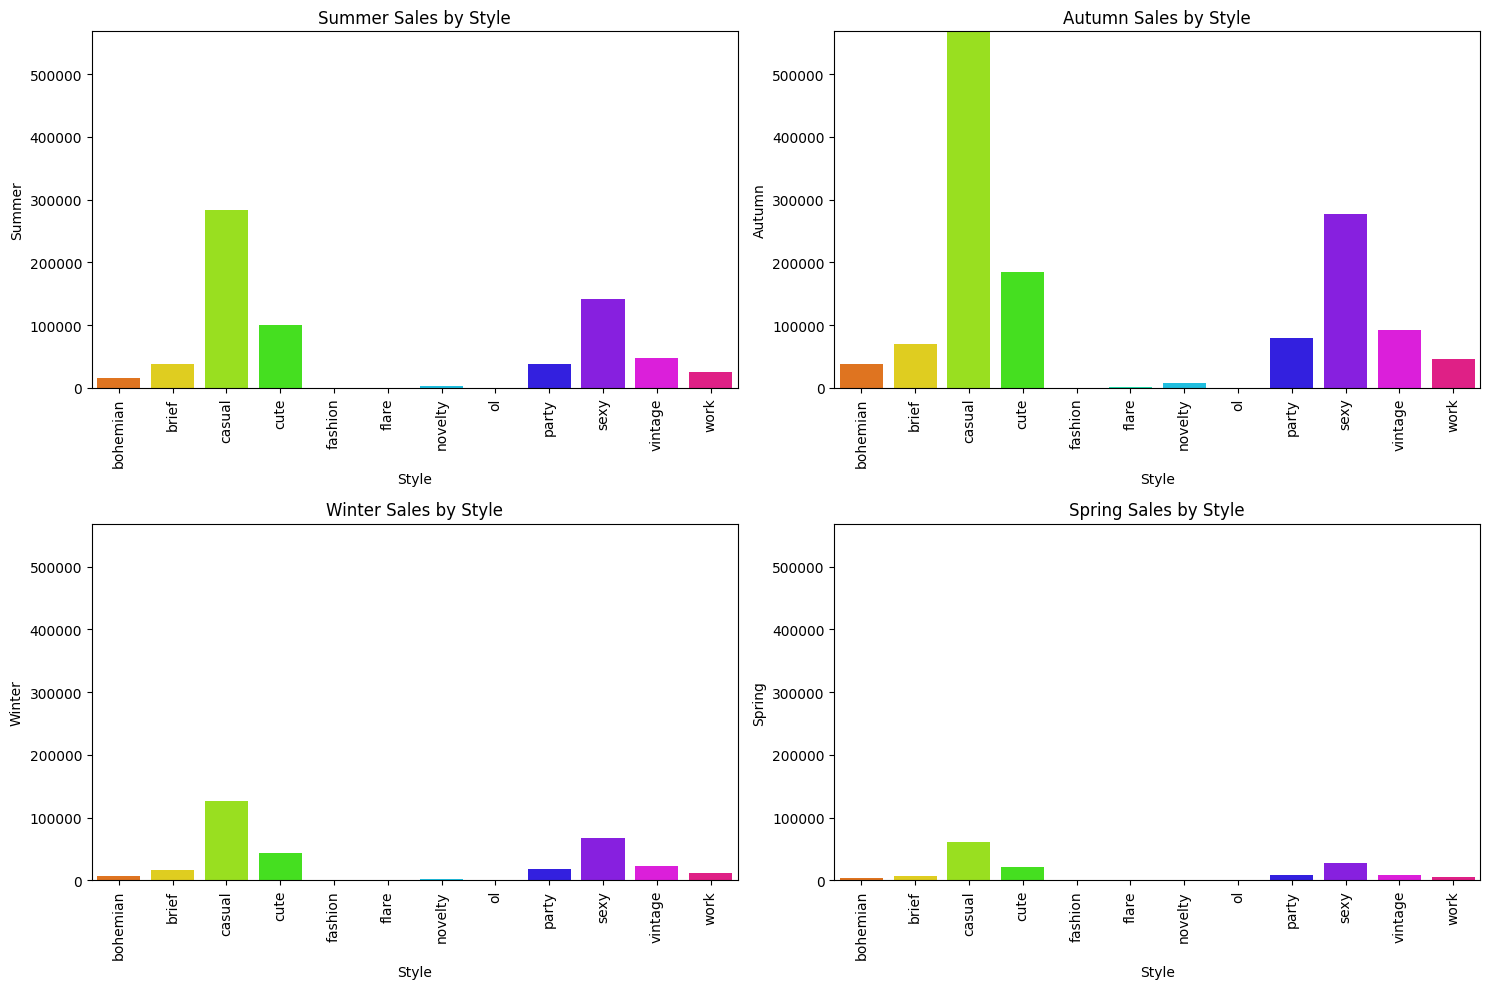

In [21]:
# Group by 'Style' and calculate the sum of sales for each season
grouped = dress_sales_df.groupby("Style")[
    ["Summer", "Autumn", "Winter", "Spring"]
].sum()
max_y = grouped[["Summer", "Autumn", "Winter", "Spring"]].values.max()

# Create subplots for each season
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

palette = sns.color_palette("hsv", len(grouped.index))  # color palette for the graphs

# Summer sales
sns.barplot(
    x=grouped.index,
    y=grouped["Summer"],
    hue=grouped.index,
    ax=axs[0, 0],
    palette=palette,
)
axs[0, 0].set_title("Summer Sales by Style")
axs[0, 0].tick_params(axis="x", rotation=90)
axs[0, 0].set_ylim([0, max_y])

# Autumn sales
sns.barplot(
    x=grouped.index,
    y=grouped["Autumn"],
    hue=grouped.index,
    ax=axs[0, 1],
    palette=palette,
)
axs[0, 1].set_title("Autumn Sales by Style")
axs[0, 1].tick_params(axis="x", rotation=90)
axs[0, 1].set_ylim([0, max_y])

# Winter sales
sns.barplot(
    x=grouped.index,
    y=grouped["Winter"],
    hue=grouped.index,
    ax=axs[1, 0],
    palette=palette,
)
axs[1, 0].set_title("Winter Sales by Style")
axs[1, 0].tick_params(axis="x", rotation=90)
axs[1, 0].set_ylim([0, max_y])

# Spring sales
sns.barplot(
    x=grouped.index,
    y=grouped["Spring"],
    hue=grouped.index,
    ax=axs[1, 1],
    palette=palette,
)
axs[1, 1].set_title("Spring Sales by Style")
axs[1, 1].tick_params(axis="x", rotation=90)
axs[1, 1].set_ylim([0, max_y])

# Adjust the layout
plt.tight_layout()
plt.show()

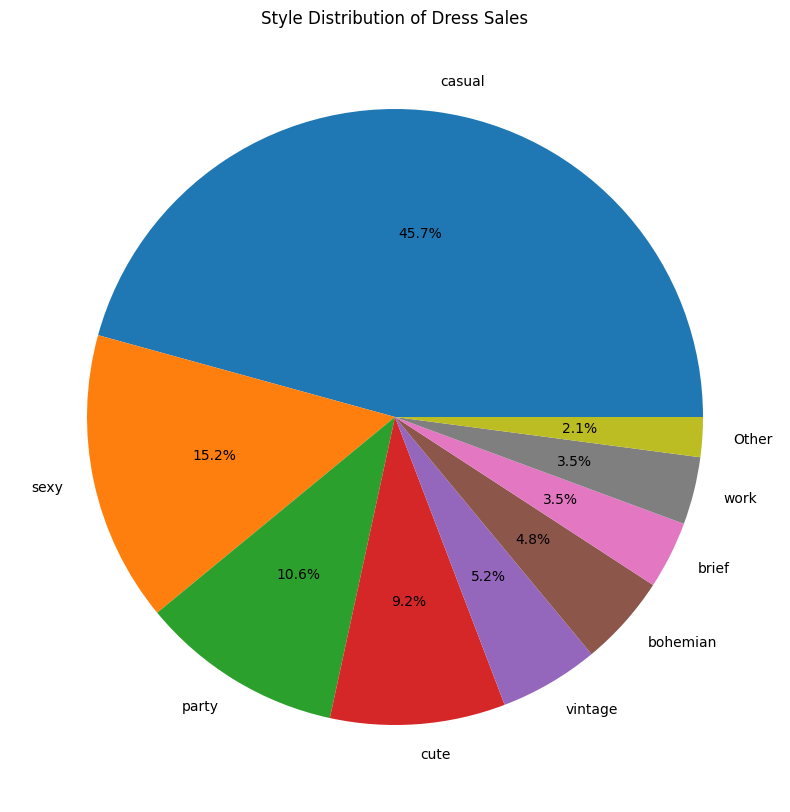

In [22]:
# Dress Style Distribution
style_counts = dress_sales_df["Style"].value_counts()

# Filter out styles with less than a certain threshold to make the pie chart more readable
threshold = 10
prominent_styles = style_counts[style_counts >= threshold]

# call all the Styles with less than 3.5 threshold as "Other"
if style_counts[style_counts < threshold].sum() > 0:
    other = pd.Series([style_counts[style_counts < threshold].sum()], index=["Other"])
    prominent_styles = pd.concat([prominent_styles, other])

# Create the pie chart
plt.figure(figsize=(14, 10))
plt.pie(prominent_styles, labels=prominent_styles.index, autopct="%1.1f%%")
plt.title("Style Distribution of Dress Sales")
plt.show()

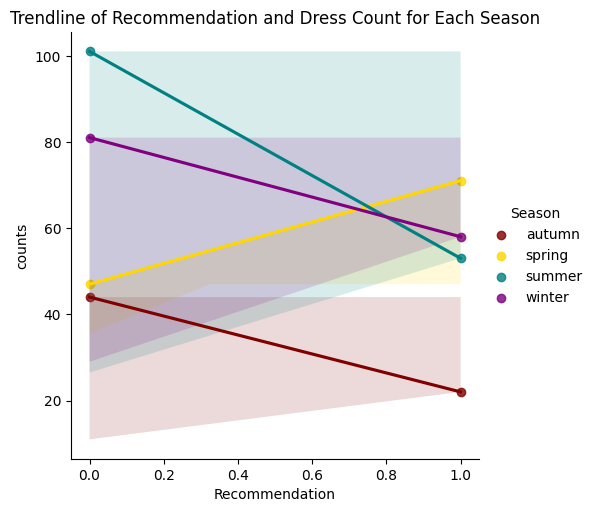

In [23]:
#  a color map for the 'Season'
colors = {"spring": "gold", "summer": "teal", "autumn": "maroon", "winter": "purple"}
count = (
    dress_sales_df.groupby(["Recommendation", "Season"])
    .size()
    .reset_index(name="counts")
)

# Create lmplot
sns.lmplot(
    x="Recommendation",
    y="counts",
    data=count,
    hue="Season",
    palette=colors,
    fit_reg=True,
)
plt.title("Trendline of Recommendation and Dress Count for Each Season")
plt.show()

In [ ]:
# Separate the seasonal and date columns
seasons = ["Summer", "Autumn", "Winter", "Spring"]
date_cols = [col for col in sales.columns if col not in seasons]


# Melt the sales data separately
sales_melted = pd.melt(
    sales[date_cols], id_vars=["Dress_ID"], var_name="Date", value_name="Sales"
)
print(
    f"salesdf melted for dates have: {sales_melted.columns} columns and the shape is {sales_melted.shape} ."
)

# Convert the 'Date' column to datetime format
sales_melted["Date"] = pd.to_datetime(
    sales_melted["Date"], format="%d-%m-%Y", errors="coerce"
)

print(
    f"sales_melted df: \n {sales_melted.head()}. \nThe null values are:\n{sales_melted.isna().sum()}"
)

In [ ]:
# Merge with attributes df and fill in the missing values for Sales only with 0.
sales_data = pd.merge(sales_melted, attributes, on="Dress_ID", how="left")
sales_data.dropna(subset=["Price"], inplace=True)
sales_data.fillna({"Sales": 0}, inplace=True)
print(
    f"Newly merge df with combined dataframes have {sales_data.shape}.\nThe Null values count in sales_data is: \n{sales_data.isna().sum()}."
)

In [ ]:
# Create new features
sales_data["On_Sale"] = sales_data["Price"].apply(lambda x: 1 if x == "low" else 0)
# Handle missing values in sales_cleaned (impute with mean)
sales_data = fill_missing_values(sales_data)
print(
    f"sales_data has the following:\n{sales_data.dtypes}",
    f"\n\nAny Null values in model ready data result : {sales_data.isna().sum().all()}.",
)
# print(sales_data.shape)
# print(sales_data["Date"].shape)

### Building the ARIMA Model:

- Before building the **ARIMA** model, we need to ensure that our data is stationary. We can use the Augmented Dickey-Fuller test for this. If the data is not stationary, we can use differencing techniques to make it stationary.
- we need to make sure data is stationary.


### Data Preparation for ARIMA (Stationary Dataset)

-- Since Data is going to be our _Index_, we need to make sure it is present and the values are unique.

## Data Preparation Process

1. **Load the Data**: Import the dataset and convert the 'Date' column to datetime format.
2. **Set the Index**: Ensure the 'Date' column is set as the index.
3. **Create Lagged Features**: Generate lagged features for the 'Sales\_\_' columns.
4. **Drop Duplicates**: Remove any duplicate rows based on the 'Date' column.
5. **Split the Data**: Divide the data into training and testing sets.
6. **Set Frequency**: Ensure the frequency of the `DateTimeIndex` is set.


In [27]:
if "Date" not in sales_data.columns:
    raise KeyError("'Date' column is missing from the DataFrame")

**\*sales_data** is in LONG format as it has duplicate dates for unique dress_ID. ARIMA data processing steps would drop the duplicates for index so all the data would be last. To mitigate the lost of the rows, we can pivot the dress_ID data into each column.\*


In [28]:
pivoted_sales = sales_data.pivot_table(
    index="Date", columns="Dress_ID", values="Sales", aggfunc="sum"
)
pivoted_sales.columns = [f"Sales_{col}" for col in pivoted_sales.columns]
pivoted_sales.shape

(23, 477)

In [ ]:
pivoted_sales.head()

In [30]:
other_cols = (
    sales_data.drop(["Sales"], axis=1)
    .drop_duplicates(subset=["Date"])
    .reset_index(drop=True)
)
merged_data = pd.merge(pivoted_sales.reset_index(), other_cols, on="Date", how="left")
# merged_data["Date"] = pd.to_datetime(merged_data["Date"])
# merged_data.set_index("Date", inplace=True)

In [31]:
categorical_cols = [
    "Style",
    "Size",
    "Season",
    "NeckLine",
    "SleeveLength",
    "Material",
    "FabricType",
    "Decoration",
    "Pattern Type",
]

encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(merged_data[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_data, columns=encoder.get_feature_names_out(categorical_cols)
)

In [32]:
ordinal_encoder = OrdinalEncoder(categories=[["low", "average", "high", "very-high"]])
merged_data["Price_encoded"] = ordinal_encoder.fit_transform(merged_data[["Price"]])
merged_data.drop("Price", axis=1, inplace=True)

In [36]:
final_data = pd.concat([merged_data.drop(categorical_cols, axis=1), encoded_df], axis=1)

In [38]:
# Split the data into training and testing sets
split_point = int(len(final_data) * 0.8)
train, test = final_data[:split_point], final_data[split_point:]

print(f"Training data shape: {train.shape}")
print(f"Testing data shape: {test.shape}")

Training data shape: (18, 492)
Testing data shape: (5, 492)


In [39]:
lagged_data = create_lags(train.copy(), 3)
train = pd.concat([train, lagged_data], axis=1)
train.shape

(18, 2416)

In [40]:
# Ensure 'Date' column exists and remove any duplicate 'Date' columns
if "Date" in train.columns:
    train = train.loc[:, ~train.columns.duplicated()]

# Convert 'Date' to datetime format, then drop duplicates and set the index
train["Date"] = pd.to_datetime(train["Date"], errors="coerce")
train = train.drop_duplicates(subset="Date")
train.set_index("Date", inplace=True)
train = create_cyclic_features_month(train)
print(train.shape)

(18, 1925)


In [41]:
# Infer and set the frequency of the DateTimeIndex
train.index.freq = pd.infer_freq(train.index)

In [ ]:
train

## Model Building and Evaluation


### Step 1: _Dickey-Fuller Test_

-Perform the Dickey-Fuller test to check for stationarity in the time series data.


In [43]:
# Dickey-Fuller Test
def adf_test(series):
    if series.nunique() == 1:
        print("Series is constant; skipping Dickey-Fuller test.")
        return
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    for key, value in result[4].items():
        print("Critical Values:")
        print(f"   {key}, {value}")

In [ ]:
# Perform Dickey-Fuller Test on each 'Sales__' column
for col in train.columns:
    if col.startswith("Sales_"):
        print(f"\nDickey-Fuller Test for {col}:")
        adf_test(train[col])

## Findings of Dickey-Fuller Test:

since there are so many series, here's how to interpret the findings for one series:

- The Dickey-Fuller test yielded a test statistic of -10.8, which is substantially below the critical values.
- Additionally, the associated p-value is extremely low at 3.34e-21 which is very close to zero.
- These results provide overwhelming evidence to reject the null hypothesis of a unit root, suggesting that the time series is stationary.


### Step 2: _Grid Search for ARIMA Order_


In [45]:
# Grid Search for ARIMA order
def grid_search_arima(data, p_values, d_values, q_values):
    best_score, best_cfg = float("inf"), None
    for p, d, q in product(p_values, d_values, q_values):
        order = (p, d, q)
        try:
            model = ARIMA(data, order=order)
            model_fit = model.fit()
            rmse = np.sqrt(mean_squared_error(data, model_fit.fittedvalues))
            if rmse < best_score:
                best_score, best_cfg = rmse, order
            # print(f"ARIMA{order} RMSE={rmse}")
        except:
            continue
    # print(f"Best ARIMA{best_cfg} RMSE={best_score}")
    return best_cfg

In [ ]:
# train.columns

In [47]:
# Define p, d, q ranges
p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)

# Perform grid search for each 'Sales__' column
best_orders = {}
for col in train.columns:
    if col.startswith("Sales_"):
        # print(f"\nGrid Search for {col}:")
        best_order = grid_search_arima(
            train[col].dropna(), p_values, d_values, q_values
        )
        best_orders[col] = best_order

-- _Grid Search out put Sample_

Grid Search for Sales_1253973206_Lag_3:
ARIMA(0, 0, 0) RMSE=138.1544335155412
ARIMA(0, 0, 1) RMSE=129.2205605065997
ARIMA(0, 0, 2) RMSE=124.63454104699647
ARIMA(0, 0, 3) RMSE=124.12327772439771
ARIMA(0, 1, 0) RMSE=145.7940327997
ARIMA(0, 1, 1) RMSE=142.1353246221507
ARIMA(0, 1, 2) RMSE=135.00095864506824
ARIMA(0, 1, 3) RMSE=129.34206604154764
ARIMA(1, 0, 0) RMSE=126.98086817411811
ARIMA(1, 0, 1) RMSE=126.91924971292694
ARIMA(1, 0, 2) RMSE=121.43246411792657
ARIMA(1, 0, 3) RMSE=119.37871092856471
ARIMA(1, 1, 0) RMSE=142.1521840085692
ARIMA(1, 1, 1) RMSE=140.92719243924248
ARIMA(1, 1, 2) RMSE=131.83546650607934
ARIMA(1, 1, 3) RMSE=125.18279847540451
ARIMA(2, 0, 0) RMSE=126.80645915149911
ARIMA(2, 0, 1) RMSE=126.17455193380238
ARIMA(2, 0, 2) RMSE=113.53267740104911
ARIMA(2, 0, 3) RMSE=113.25579248543063
ARIMA(2, 1, 0) RMSE=141.9831562471301
...
ARIMA(3, 1, 2) RMSE=122.58509431838252
ARIMA(3, 1, 3) RMSE=121.8424500962646
Best ARIMA(3, 0, 3) RMSE=112.62343399774727


In [ ]:
print(best_orders)

### Step 3: _Fit ARIMA_

### Step 4: _Evaluate the Model_

- Evaluate the model on the testing set by forecasting and calculating the RMSE.


In [ ]:
forecasts = {}
for col, order in best_orders.items():
    series_train = train[col].dropna()
    series_test = test[col].dropna()
    if series_train.ndim == 1 and series_test.ndim == 1:
        model = ARIMA(series_train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=len(series_test))
        forecasts[col] = forecast
    else:
        print(f"Error: {col} is not one-dimensional")

In [ ]:
# ARIMA output result sample since above results are too long

# <!-- ARIMA Model Summary for Sales_1225512606_Lag_3:

# SARIMAX Results
# ----------------
# Dep. Variable: Sales_1225512606_Lag_3 No. Observations: 20

# Model: ARIMA(3, 0, 3) Log Likelihood -48.491
# Date: Fri, 02 Aug 2024 AIC 112.983
# Time: 08:40:41 BIC 120.949
# Sample: 0 HQIC 114.538 - 20
# Covariance Type: opg
# ---------------------
# coef std err z P>|z| [0.025 0.975]

# ---

In [ ]:
# # Combine forecasts into a single DataFrame
# forecast_df = pd.DataFrame(forecasts, index=test.index)

# print(forecast_df)

## _Interpretation of Results_

- **ADF Statistic and p-value**: The Dickey-Fuller test results indicate whether the series is stationary. A lower p-value (< 0.05) suggests that the series is stationary.
- **Best ARIMA Order**: The grid search identifies the best ARIMA order (p, d, q) based on RMSE.
- **Model Summary**: The ARIMA model summary provides details about the fitted model, including coefficients and diagnostics.
- **RMSE**: The Root Mean Squared Error (RMSE) on the testing set indicates the model's forecasting accuracy.

## _Conclusion and Recommendations_

Based on the analysis and model evaluation:

- **Stationarity**: Ensure the time series data is stationary before fitting the ARIMA model.
- **Model Selection**: Use grid search to identify the best ARIMA order for each 'Sales\_' column.
- **Model Performance**: Evaluate the model's performance using RMSE and adjust the model parameters as needed.
- **Future Work**: Explore other time series models and techniques to improve forecasting accuracy.


## Enhancements:

-Since the above model gives the RMSE of each Sales* column which is essentially the sales for each unique Dress_ID, let's generate forecasts for each Sales* column and combine them in a data frame. From there we can see how to combine the forecasts to predict which Dress attributes would result in the best sales as well for further enhancements on ARIMA.


### Fit ARIMA Model using the best order on the training set and generate forecasts


TO BE IMPLEMENTED
-- since model took 5 hours or more to run, the new forecast enhancement into a date frame is going to have to wait until model is finished running.


In [ ]:
# Prepare for the animation
# TODO